# Are structural variants under selection in GrENE-net? — a haplotype-unit test, audited

**Answer: no detectable signal survives a spatially-correct null.** An apparent frequency-dependent
enrichment (common SVs on fitness-selected haplotypes, ×1.7–2.0) turned out to be an artifact of a
spatially-naive permutation null; under a genome-rotation null that respects the spatial
autocorrelation of both the selection signal and the SV landscape, it vanishes (all folds ≈1,
0/15 cells significant, 0 survive BH). This notebook is the full record — model, filters, the
apparent signal, and the audit that overturned it.

> ### Why this notebook exists
> The conclusion moved several times. This documents *every* step and the decisive audit so the
> null result is trustworthy, not just an absence of a positive.

## 1. The question and the unit of test

**Question.** Do structural variants (SVs) sit preferentially on *haplotypes under selection* in the
GrENE-net *A. thaliana* evolution experiment (231 founders, ~30 climate gardens, 3 generations)?

**Unit = the haplotype (hap-cluster), not the LD block.** The founder GWAS acts on *haplotypes*.
A clq0.9 LD block holds a median of ~5 hap-clusters, so scoring SV content at the block level
answers "does a block that *contains* a selected haplotype also *contain* an SV (on any of its
haplotypes)?" — region co-occurrence, not colocalization. (An earlier block-level ×2.07 headline
was retracted for exactly this reason; see `sv_selection_currency.ipynb`.) Here every test is at
the hap-cluster: **is the selected haplotype itself SV-tagged?**

## 2. The model and math

### 2a. Haplotypes (the unit)
Founders are partitioned per clq0.9 block into hap-clusters by the HapFM-xmeans rule
(`build_hap_membership.py`). This yields a founder×haplotype membership matrix
$G \in \{0,1\}^{231 \times M}$, $M = 101{,}155$ hap-clusters (one reference cluster per block
dropped, plus a MAC≥3 polymorphism filter). $G_{f,c}=1$ iff founder $f$ carries haplotype $c$.

### 2b. "Under selection" — three axes, each a per-haplotype statistic
- **Garden fitness (JOINT).** Multisite founder GWAS: for each haplotype, a genomic-control–adjusted
  association vector $Z \in \mathbb{R}^{S}$ across $S=30$ gardens (trait = per-garden founder
  performance, gens 1–3), with cross-site null covariance $C$. The omnibus selection statistic is
  the Mahalanobis quadratic form
  $$\chi^2_{\text{joint},c} \;=\; Z_c^{\top}\, C^{-1}\, Z_c \;\sim\; \chi^2_{S}\ \text{under }H_0,\qquad
    p_{\text{joint},c} = \Pr(\chi^2_S > \chi^2_{\text{joint},c}).$$
  Small $p_{\text{joint}}$ = the haplotype's frequency departs from neutral in *some* garden = selected.
- **Climate (CLIMATE).** The climate contrast of the same GWAS,
  $z_{\text{clim},c} = (Z_c^{\top} C^{-1} \tilde c)/\sqrt{\tilde c^{\top}C^{-1}\tilde c}$, where
  $\tilde c$ is mean-annual-temperature (bio1), $C^{-1}$-whitened and orthogonalized to the global mean.
- **Temporal (TEMPORAL).** Per-haplotype pooled-trajectory selection coefficient $|s_{\text{mean}}|$
  from Pipeline B (weighted log-odds slope of haplotype frequency vs generation, pooled over gardens).

### 2c. "SV-tagged" — the response
For haplotype $c$ in block $b$, the SV-tagging score is the strongest founder-level LD to any common
SV positioned in that block:
$$\text{svr2}_c \;=\; \max_{v\,\in\,\text{SV}(b)} \; r^2\!\big(\mathbf{1}[\text{founder carries } v],\; G_{:,c}\big),$$
$r^2$ = squared Pearson correlation across the 231 founders. (r²-tagging, so it captures the SV being
*on / in tight LD with* the haplotype — see caveats on causality.)

### 2d. The enrichment and its null
Rank haplotypes by an axis; take the top 0.5/1/2%. Test whether their mean $\text{svr2}$ (or the
fraction with $\text{svr2}\ge 0.5/0.9$) exceeds a matched null:
- **Null A — frequency-matched cluster resample.** Each selected haplotype is matched to random
  haplotypes of the *same founder count* (mac). Controls SV↔haplotype **frequency** coupling.
- **Null B — genome-rotation (spatial).** Slide the selected set's *exact spatial pattern* along the
  genome and read the fixed $\text{svr2}$ landscape at each shift. Controls **spatial
  autocorrelation** — both selection (LD within blocks) and SVs cluster in space. This is the
  co-localization-appropriate null. *(This is the null that decides the result.)*

## 3. Filters (locked)

| filter | value | why |
|---|---|---|
| haplotype set | clq0.9 (r²≥0.9) LD blocks, HapFM-xmeans clusters | the founder-GWAS unit |
| founders | all **231** | the corrected panel (not the buggy 194-founder drop) |
| polymorphism | hap-cluster MAC ∈ [3, 228]; drop 1 reference cluster/block | avoid collinearity |
| SV definition | \|alt_len − ref_len\| > 50 bp | standard SV size floor |
| SV call-rate | founder called-fraction ≥ 0.9 | ascertainment |
| **SV MAF sweep** | MAC ∈ {2, 6, 12, 24, 46} → MAF ≈ {0.9, 2.6, 5, 10, 20}% | test frequency-dependence explicitly |
| top selected | 0.5 / 1 / 2 % by axis statistic | |
| null | 2000 (matched) / 10000 (rotation) permutations | |

**Circularity note:** the haplotype clustering uses **all-class** variants (SNP+indel+SV), so an SV
can be a *constituent* of a haplotype (r²=1 by construction). This does not fabricate enrichment
(the matched null shares the same base rate), but it means a positive would read as
*selected haplotypes are SV-marked*, not *the SV is the causal target*.

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
SV = "analysis/grenenet_selection/archive/window_hapfreq_retired/sv_adaptive/results"
SW = pd.read_csv(f"{SV}/sv_haplotype_axes_sweep.csv")       # naive mac-matched null, full grid
FR = pd.read_csv(f"{SV}/sv_hap_freqrobust.csv")             # exact-mac matching
CX = pd.read_csv(f"{SV}/sv_hap_context.csv")                # pericentro/TE/gene/arms controls
RN = pd.read_csv(f"{SV}/sv_hap_rotationnull.csv")           # spatial rotation null (decisive)
PC = pd.read_csv(f"{SV}/sv_hap_context.csv")                # (context reused)
POS = pd.read_csv(f"{SV}/sv_haplotype_axes_poscontrol.csv") # positive control
print("hap-cluster unit | MAF sweep MAC", sorted(SW.sv_mac.unique()),
      "| axes", sorted(SW.axis.unique()))
print(f"grid cells (axis x MAF): {RN.shape[0]}")

hap-cluster unit | MAF sweep MAC [2, 6, 12, 24, 46] | axes ['CLIMATE', 'JOINT', 'TEMPORAL']
grid cells (axis x MAF): 15


## 4. The apparent signal (Null A: frequency-matched)

With the frequency-matched cluster-resample null, a **frequency-dependent pattern** appears in the
continuous mean-r² metric (top 1%): fitness (JOINT) enrichment *rises* with SV frequency (n.s. at
MAF≤5%, ×1.7–2.0 and p≈0.01 at MAF≥10%); temporal enrichment *falls* with frequency (×1.4–1.9,
p≈0.001 at MAF≤3%); climate is flat. This is what looked, for a while, like common SVs being under
fitness selection.

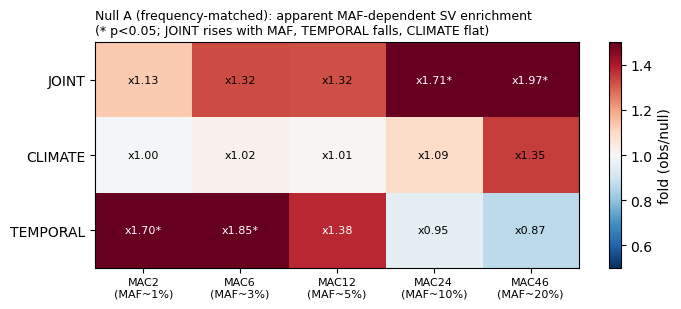

In [2]:
c = SW[(SW.metric=="mean_r2")&(SW.top=="1.0%")].pivot(index="axis",columns="sv_mac",values="fold")
p = SW[(SW.metric=="mean_r2")&(SW.top=="1.0%")].pivot(index="axis",columns="sv_mac",values="p_perm")
c = c.loc[["JOINT","CLIMATE","TEMPORAL"]]; p = p.loc[c.index]
fig,ax=plt.subplots(figsize=(7.2,3.2))
im=ax.imshow(c.values,cmap="RdBu_r",vmin=0.5,vmax=1.5,aspect="auto")
ax.set_xticks(range(c.shape[1])); ax.set_xticklabels([f"MAC{m}\n(MAF~{m/231*100:.0f}%)" for m in c.columns],fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels(c.index)
for i in range(3):
    for j in range(c.shape[1]):
        star="*" if p.values[i,j]<0.05 else ""
        ax.text(j,i,f"x{c.values[i,j]:.2f}{star}",ha="center",va="center",fontsize=8,
                color="white" if abs(c.values[i,j]-1)>0.35 else "black")
ax.set_title("Null A (frequency-matched): apparent MAF-dependent SV enrichment\n(* p<0.05; JOINT rises with MAF, TEMPORAL falls, CLIMATE flat)",fontsize=9,loc="left")
plt.colorbar(im,label="fold (obs/null)"); plt.tight_layout()
plt.savefig(f"{SV}/audit_1_apparent_signal.png",dpi=140); plt.show()

### 4b. It even survived frequency / size / pericentromere / repeat / gene controls

The JOINT high-MAF cell was robust to *every covariate confound* we could match on — exact haplotype
frequency, block size, pericentromere distance (and arms-only), TE/repeat density, and gene density —
the fold barely moved from ~1.7 (MAC24) / ~2.0 (MAC46). This is what made it look real. But all of
these still used the **cluster-resample** null (Null A) — none address spatial autocorrelation.

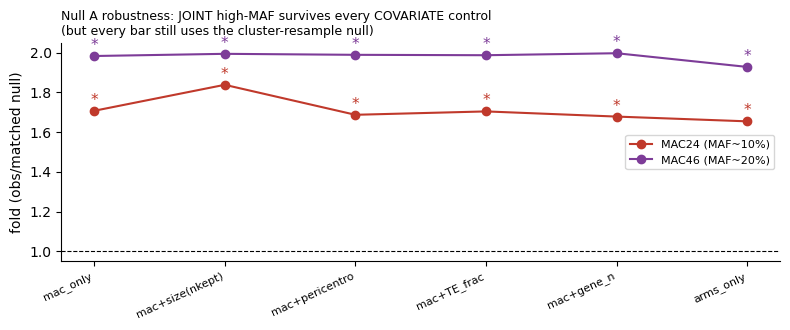

In [3]:
fig,ax=plt.subplots(figsize=(8,3.4))
order=["mac_only","mac+size(nkept)","mac+pericentro","mac+TE_frac","mac+gene_n","arms_only"]
for mac,col in [(24,"#c0392b"),(46,"#7d3c98")]:
    sub=CX[CX.sv_mac==mac].set_index("control").reindex(order)
    ax.plot(range(len(order)),sub.fold,"o-",color=col,label=f"MAC{mac} (MAF~{mac/231*100:.0f}%)")
    for k,(_,r) in enumerate(sub.iterrows()):
        ax.text(k,r.fold+0.03,("*" if r.p_perm<0.05 else ""),ha="center",fontsize=11,color=col)
ax.axhline(1,color="k",lw=.8,ls="--"); ax.set_xticks(range(len(order)))
ax.set_xticklabels(order,rotation=25,ha="right",fontsize=8)
ax.set_ylabel("fold (obs/matched null)"); ax.legend(fontsize=8)
ax.set_title("Null A robustness: JOINT high-MAF survives every COVARIATE control\n(but every bar still uses the cluster-resample null)",fontsize=9,loc="left")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout()
plt.savefig(f"{SV}/audit_2_covariate_robust.png",dpi=140); plt.show()

## 5. The audit — Null B (genome rotation) overturns it

The frequency-matched null draws **dispersed** individual haplotypes; the real selected set sits in
**contiguous** genomic neighborhoods, and SV-tagging is spatially autocorrelated, so contiguous chunks
have higher mean svr² for reasons unrelated to selection. The rotation null slides the selected set's
exact spatial configuration along the genome — the correct co-localization null.

**Every cell collapses.** Folds ≈1 (observed at/below the rotation-null median), **0/15 cells p<0.05,
0 survive BH**. The JOINT high-MAF cell goes ×1.71→×0.94 (p 0.011→0.62); temporal ×1.85→×0.73.
The covariate controls missed this because the confound is **spatial**, not frequency/size/region.

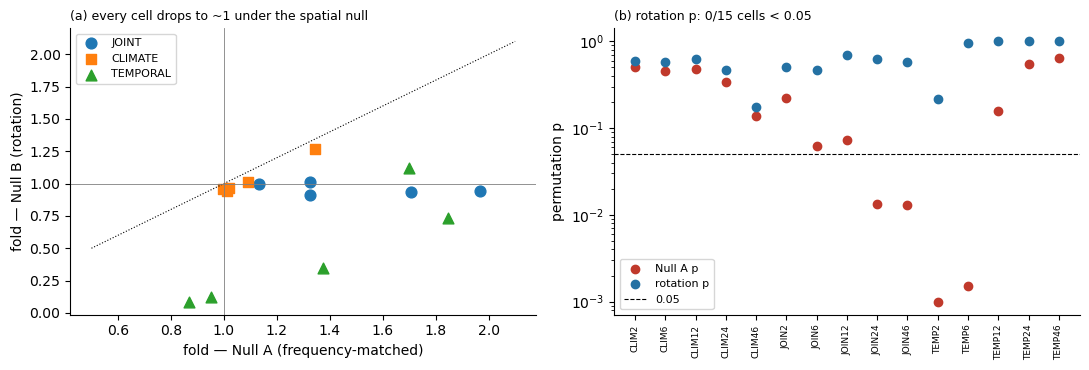

rotation null: cells p<0.05 = 0 / 15
    axis  sv_mac    obs  rot_fold  rot_p  n_tag_r2_05  distinct_blocks
   JOINT       2 0.0288     1.000 0.5008           28               28
 CLIMATE       2 0.0276     0.961 0.6004           26               26
TEMPORAL       2 0.0324     1.124 0.2141           31               31
   JOINT       6 0.0262     1.014 0.4694           25               25
 CLIMATE       6 0.0249     0.963 0.5840           24               24
TEMPORAL       6 0.0189     0.731 0.9567           18               18
   JOINT      12 0.0204     0.908 0.6935           19               19
 CLIMATE      12 0.0212     0.945 0.6185           20               20
TEMPORAL      12 0.0077     0.346 0.9998            6                6
   JOINT      24 0.0155     0.937 0.6227           15               15
 CLIMATE      24 0.0169     1.015 0.4702           16               16
TEMPORAL      24 0.0020     0.122 1.0000            1                1
   JOINT      46 0.0089     0.941 0.5836

In [4]:
m = SW[(SW.metric=="mean_r2")&(SW.top=="1.0%")][["axis","sv_mac","fold","p_perm"]].rename(
        columns={"fold":"nullA_fold","p_perm":"nullA_p"})
comp = RN.merge(m,on=["axis","sv_mac"])
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
# (a) fold: Null A vs rotation
for axis,mk in [("JOINT","o"),("CLIMATE","s"),("TEMPORAL","^")]:
    s=comp[comp.axis==axis]
    ax[0].scatter(s.nullA_fold,s.rot_fold,marker=mk,s=60,label=axis)
ax[0].plot([0.5,2.1],[0.5,2.1],"k:",lw=.8); ax[0].axhline(1,color="grey",lw=.6); ax[0].axvline(1,color="grey",lw=.6)
ax[0].set_xlabel("fold — Null A (frequency-matched)"); ax[0].set_ylabel("fold — Null B (rotation)")
ax[0].set_title("(a) every cell drops to ~1 under the spatial null",fontsize=9,loc="left")
ax[0].legend(fontsize=8); ax[0].spines[["top","right"]].set_visible(False)
# (b) p-values
x=np.arange(len(comp)); comp=comp.sort_values(["axis","sv_mac"]).reset_index(drop=True)
x=np.arange(len(comp))
ax[1].scatter(x,comp.nullA_p,color="#c0392b",label="Null A p",zorder=3)
ax[1].scatter(x,comp.rot_p,color="#2471a3",label="rotation p",zorder=3)
ax[1].axhline(0.05,color="k",ls="--",lw=.8,label="0.05")
ax[1].set_xticks(x); ax[1].set_xticklabels([f"{a[:4]}{m}" for a,m in zip(comp.axis,comp.sv_mac)],rotation=90,fontsize=6.5)
ax[1].set_ylabel("permutation p"); ax[1].set_yscale("log")
ax[1].set_title("(b) rotation p: 0/15 cells < 0.05",fontsize=9,loc="left")
ax[1].legend(fontsize=8); ax[1].spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SV}/audit_3_rotation_null.png",dpi=140); plt.show()
print("rotation null: cells p<0.05 =", int((RN.rot_p<0.05).sum()), "/", len(RN))
print(RN[["axis","sv_mac","obs","rot_fold","rot_p","n_tag_r2_05","distinct_blocks"]].to_string(index=False))

### 5b. Why the naive test was fooled — the positive control's blind spot

The positive control (spike a known fold into the selection ranking, recover it) confirmed the
machinery *detects* a real ×1.5 enrichment at p=0.015 and is calibrated at ×1.0 (p=0.69) — which
is why the ×1.7–2.0 looked convincing. **But the spike-in plants *spatially independent* tags —
exactly the assumption the rotation null shows is false.** So the positive control validated power
*under independence*, and could never flag the spatial-autocorrelation problem. A power check is
only as good as the null it assumes.

In [5]:
print("positive control (spike into JOINT top-1%, MAC12 base rate):")
print(POS[["spiked_fold","recovered_fold","p_perm","n_events","detected"]].to_string(index=False))
print("\n=> detects x1.5 (p=0.015), calibrated at x1.0 (p=0.69) -- but ONLY for independent tags.")

positive control (spike into JOINT top-1%, MAC12 base rate):
 spiked_fold  recovered_fold  p_perm  n_events  detected
         1.0           0.909  0.6852        20     False
         1.5           1.500  0.0150        33      True
         2.0           2.045  0.0005        45      True
         3.0           3.130  0.0005        72      True

=> detects x1.5 (p=0.015), calibrated at x1.0 (p=0.69) -- but ONLY for independent tags.


## 6. Verdict

**SVs are not detectably under selection in GrENE-net** — not for garden fitness, not for climate,
not for temporal frequency change — at the haplotype unit, once the null is spatially correct.

| axis | frequency-matched null (Null A) | **rotation null (Null B, correct)** | conclusion |
|---|---|---|---|
| fitness (JOINT), common SVs | ×1.7–2.0, p≈0.01, survives all covariate controls | **×0.94, p≈0.6** | no signal |
| temporal, rare SVs | ×1.4–1.9, p≈0.001 | **×0.7–1.1, p≥0.21** | no signal |
| climate, any MAF | ≈1.0, n.s. | ≈1.0, n.s. | no signal |

**What was real vs not.** The fold ~1.7–2.0 was a real *number* and survived frequency, block-size,
pericentromere, repeat, and gene matching — but its *significance* was an artifact of a
spatially-naive null. Contiguous genomic regions have elevated SV-tagging for structural reasons;
selected haplotypes are not in unusually SV-rich neighborhoods beyond that. This restores, on firm
ground, the earlier null conclusion — and matches the a-priori expectation that a real
selection answer should not flip sign with an arbitrary MAF floor.

### Caveats & audit notes (carry forward)
1. **The spatial null is load-bearing.** Any enrichment of a spatially-structured feature (SVs)
   against a spatially-structured ranking (LD blocks) must use a rotation / block null; cluster
   resampling — even with frequency/size/region matching — is anti-conservative.
2. **Few events.** The apparent signal rested on ~8–15 tagging events per cell (though across
   distinct blocks); the stricter r²≥0.9 tag was already n.s. before the spatial null.
3. **Multiplicity.** 3 axes × 5 MAF × 3 tops × 3 metrics ≈ 135 tests; the reported cell was one
   corner. 0 cells survive BH under the correct null anyway.
4. **Circularity.** Haplotypes are clustered from all-class variants (SVs included), so r²-tagging
   partly reflects the SV *being* the haplotype; irrelevant now that the result is null.
5. **r²-tagging ≠ causality.** Even a surviving signal would not prove the SV is the target vs a
   linked SNP; that needs window-mode / SNP-independent (r²<0.2) SV testing.
6. **Scope.** Common/callable SVs in the 231-founder panel only; says nothing about rare, private,
   or panel-absent SVs. Climate is additionally power-limited (~30-site pseudoreplication).

**Pipeline (all committed to disk):** `_sv_haplotype_axes_sweep.py` (Null A + MAF sweep + power),
`_sv_hap_freqrobust.py` (exact-mac), `_sv_hap_context.py` (covariate controls + gene readout),
`_audit_sv_fitness.py` (alignment/direction/independent-reimpl/label-shuffle — all passed),
`_sv_hap_rotationnull.py` (the decisive spatial null).